# 02 · Resultados, comparación e incertidumbre

**Pregunta:** ¿añadir sentimiento mejora realmente al modelo financiero base?

Este cuaderno lee la ejecución corregida `review-full-20260908`. No reentrena modelos y no descarga datos. Distingue las métricas de clasificación de la rentabilidad, y los resultados actuales de los antecedentes históricos.

## Recorrido
1. Identificar los artefactos y comprobar las predicciones.
2. Comparar base e híbrido con el baseline a la vista.
3. Examinar variantes, bloques externos y empresas.
4. Interpretar intervalos e historia del experimento.

**Preparación:** ejecutar las celdas en orden con las dependencias del proyecto. No hacen falta los modelos `.joblib` ni las carpetas locales ignoradas para leer estos resultados.

## 1. Ejecución y archivos

El identificador es fijo para evitar mezclar resultados con ejecuciones de verificación. Todos los archivos siguientes pertenecen a la misma evaluación externa.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src").is_dir() and (p / "reports").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Abre el notebook desde la raíz del proyecto o desde notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RUN_ID = "review-full-20260908"
RUN = ROOT / "reports" / "experiments" / RUN_ID
manifest = json.loads((RUN / "manifest.json").read_text(encoding="utf-8"))
assert manifest["status"] == "complete", "La ejecución seleccionada no está completa."
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110, "font.size": 10})
pd.set_option("display.max_columns", 12)
display(Markdown(f"**Ejecución seleccionada:** `{RUN_ID}`. Histórico exploratorio, no holdout independiente."))

**Ejecución seleccionada:** `review-full-20260908`. Histórico exploratorio, no holdout independiente.

In [2]:
metrics = pd.read_csv(RUN / "metrics" / "global_metrics.csv")
detail = pd.read_csv(RUN / "metrics" / "metrics.csv")
intervals = pd.read_csv(RUN / "metrics" / "auc_intervals.csv")
predictions = pd.read_csv(RUN / "predictions" / "predictions.csv", parse_dates=["Date"])
selection = pd.read_csv(RUN / "tuning" / "selected_params.csv")
display(pd.DataFrame({
    "artefacto": ["Grupos de métricas", "Predicciones almacenadas", "Intervalos de diferencias", "Modelos externos"],
    "filas": [len(metrics), len(predictions), len(intervals), len(selection)],
}))
display(Markdown("**Advertencia metodológica:** el histórico ya había sido inspeccionado. La validación corregida no lo convierte en un holdout independiente."))

,artefacto,filas
0,Grupos de métricas,61
1,Predicciones almacenadas,134932
2,Intervalos de diferencias,62
3,Modelos externos,183


**Advertencia metodológica:** el histórico ya había sido inspeccionado. La validación corregida no lo convierte en un holdout independiente.

## 2. Consistencia de las predicciones

Se verifica que cada modelo predice las mismas empresas y fechas y que su AUC coincide con el CSV de métricas. No se cargan ni ejecutan modelos serializados.

In [3]:
from sklearn.metrics import roc_auc_score
keys = ["dataset_type", "model_name"]
assert not predictions.duplicated(keys + ["ticker", "Date"]).any()
groups = predictions.groupby(keys)
reference = predictions.query("dataset_type == 'base' and model_name == 'dummy'").sort_values(["Date", "ticker"])[["Date", "ticker", "target"]].reset_index(drop=True)
for _, frame in groups:
    current = frame.sort_values(["Date", "ticker"])[["Date", "ticker", "target"]].reset_index(drop=True)
    assert current.equals(reference), "No se pueden comparar grupos con observaciones distintas."
recomputed = pd.DataFrame([
    {"dataset_type": variant, "model_name": model, "auc_recalculado": roc_auc_score(frame["target"], frame["probability"])}
    for (variant, model), frame in groups
])
check = metrics.merge(recomputed, on=keys, validate="one_to_one")
assert np.allclose(check["roc_auc"], check["auc_recalculado"], atol=1e-12, rtol=0)
display(Markdown(f"**Comprobación correcta:** {len(check)} grupos, {len(reference):,} observaciones externas por grupo y AUC coherentes."))

**Comprobación correcta:** 61 grupos, 2,212 observaciones externas por grupo y AUC coherentes.

## 3. Qué significa cada métrica

| Métrica | Qué mide | Precaución |
| --- | --- | --- |
| Accuracy | Proporción de aciertos | Puede favorecer la clase mayoritaria |
| F1 positivo | Equilibrio de precisión y recall de las subidas | Ignora el F1 de la otra clase |
| Balanced accuracy | Media del recall de ambas clases | Baseline de referencia: 0,5 |
| F1 macro | Media del F1 de ambas clases | No es lo mismo que el F1 positivo |
| MCC | Asociación entre clases reales y predichas | Referencia sin asociación: 0 |
| ROC-AUC | Ordenación de probabilidades | No es porcentaje de aciertos ni rentabilidad |

La selección interna utiliza media de AUC. Para interpretar resultados externos miramos AUC, incertidumbre, métricas equilibradas y referencia trivial conjuntamente.

In [4]:
metric_columns = ["accuracy", "f1", "balanced_accuracy", "f1_macro", "mcc", "roc_auc"]
baseline = metrics.loc[metrics["model_name"].eq("dummy"), ["dataset_type", "model_name", *metric_columns]]
display(baseline.style.format({name: "{:.4f}" for name in metric_columns}))
dummy = predictions.loc[predictions["model_name"].eq("dummy")]
display(pd.crosstab(dummy["target"], dummy["prediction"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
.rename_axis(index="Clase real", columns="Clase predicha"))

,dataset_type,model_name,accuracy,f1,balanced_accuracy,f1_macro,mcc,roc_auc
0,base,dummy,0.5389,0.7004,0.5000,0.3502,0.0000,0.5000


Clase predicha,0,1
Clase real,,
0,0,1020
1,0,1192


**Lectura:** el baseline predice siempre subida. Su F1 positivo ronda 0,7004, pero su AUC es 0,5 y su MCC es cero. Una puntuación alta de F1 positivo, aislada, no demuestra discriminación.

## 4. Comparación principal: base frente a híbrido

Cada diferencia se calcula para el mismo algoritmo y las mismas observaciones. Un valor positivo favorece al híbrido en esa métrica, pero todavía no establece significación ni causalidad.

,AUC base,AUC híbrido,Delta AUC,Delta balanced accuracy,Delta MCC
model_name,,,,,
hist_gradient_boosting,0.4868,0.4932,0.0064,-0.0052,-0.0104
lightgbm,0.4920,0.4954,0.0034,0.0051,0.0103
logistic_regression,0.5040,0.4976,-0.0064,0.0064,0.0181
random_forest,0.5049,0.5018,-0.0031,0.0059,0.0122
xgboost,0.4942,0.4970,0.0028,-0.0061,-0.0119


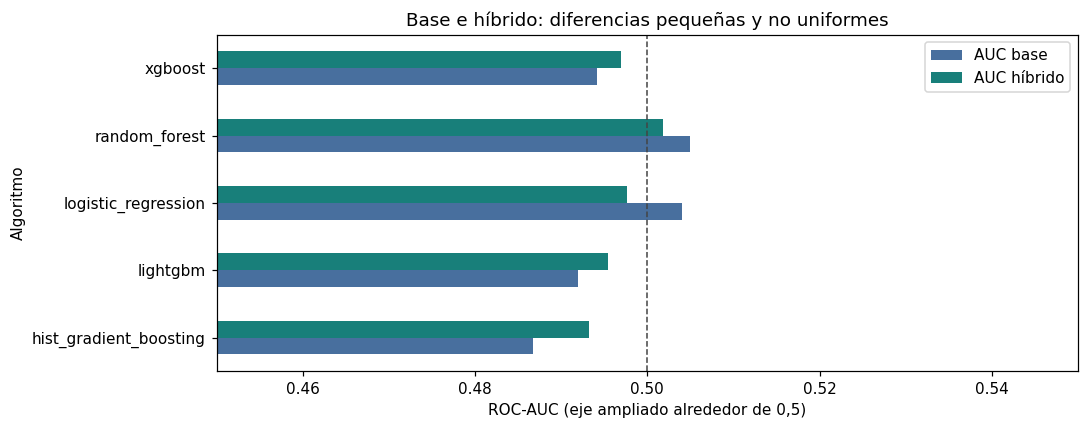

In [5]:
base = metrics.loc[metrics["dataset_type"].eq("base") & ~metrics["model_name"].eq("dummy")].set_index("model_name")
hybrid = metrics.loc[metrics["dataset_type"].eq("hybrid")].set_index("model_name")
comparison = pd.DataFrame({
    "AUC base": base["roc_auc"], "AUC híbrido": hybrid["roc_auc"],
    "Delta AUC": hybrid["roc_auc"] - base["roc_auc"],
    "Delta balanced accuracy": hybrid["balanced_accuracy"] - base["balanced_accuracy"],
    "Delta MCC": hybrid["mcc"] - base["mcc"],
})
display(comparison.style.format("{:.4f}"))
ax = comparison[["AUC base", "AUC híbrido"]].plot.barh(color=["#486f9e", "#187f7a"])
ax.axvline(0.5, color="#444444", linestyle="--", linewidth=1)
ax.set(xlim=(0.45, 0.55), xlabel="ROC-AUC (eje ampliado alrededor de 0,5)", ylabel="Algoritmo", title="Base e híbrido: diferencias pequeñas y no uniformes")
plt.tight_layout()
plt.show()

## 5. Variantes y criterios de resumen

El mayor AUC agrupado y la mayor media de AUC por bloque pueden corresponder a modelos distintos. El AUC agrupado mezcla puntuaciones de modelos ajustados en momentos diferentes. El máximo observado entre muchas alternativas se identifica solo de forma descriptiva.

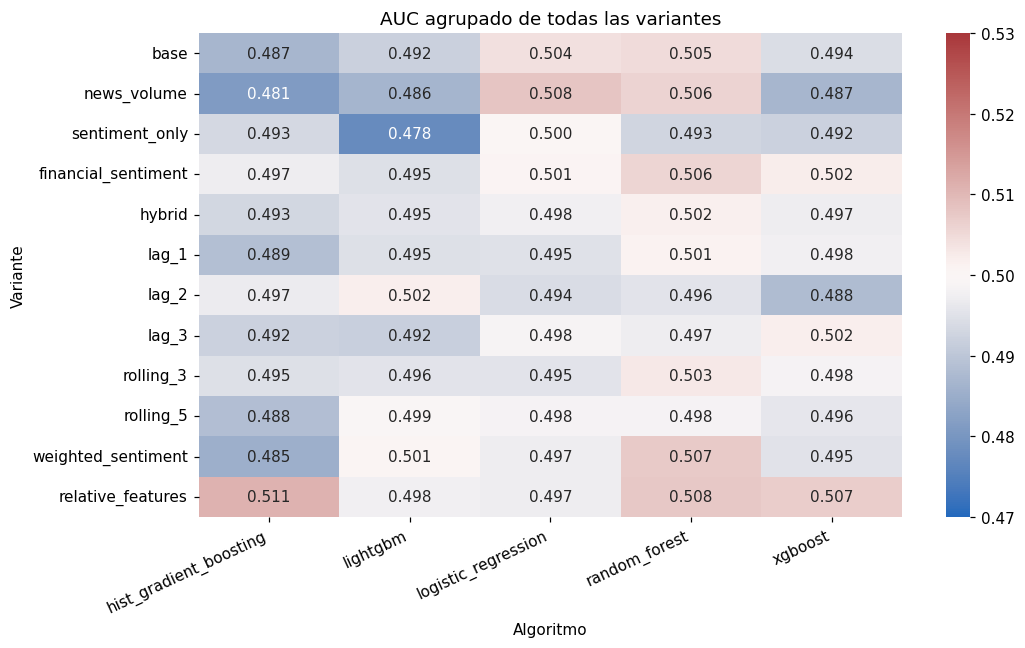

,criterio,dataset_type,model_name,roc_auc,mean_outer_auc
0,Mayor AUC agrupado,relative_features,hist_gradient_boosting,0.5108,0.5099
1,Mayor media de AUC externo,weighted_sentiment,random_forest,0.5075,0.5181


In [6]:
import seaborn as sns
ordered = list(manifest["feature_sets"])
auc_table = metrics.loc[~metrics["model_name"].eq("dummy")].pivot(index="dataset_type", columns="model_name", values="roc_auc").reindex(ordered)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(auc_table, annot=True, fmt=".3f", cmap="vlag", center=0.5, vmin=0.47, vmax=0.53, ax=ax)
ax.set(title="AUC agrupado de todas las variantes", xlabel="Algoritmo", ylabel="Variante")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
winners = pd.DataFrame([
    {"criterio": "Mayor AUC agrupado", **metrics.loc[metrics["roc_auc"].idxmax(), ["dataset_type", "model_name", "roc_auc", "mean_outer_auc"]].to_dict()},
    {"criterio": "Mayor media de AUC externo", **metrics.loc[metrics["mean_outer_auc"].idxmax(), ["dataset_type", "model_name", "roc_auc", "mean_outer_auc"]].to_dict()},
])
display(winners.style.format({"roc_auc": "{:.4f}", "mean_outer_auc": "{:.4f}"}))

## 6. Estabilidad por bloque y por empresa

Los tres bloques evalúan periodos distintos. Sus modelos se reentrenan de forma expansiva. El desglose por empresa permite explorar heterogeneidad, pero no confirma por sí solo una hipótesis sobre TSLA o NVDA.

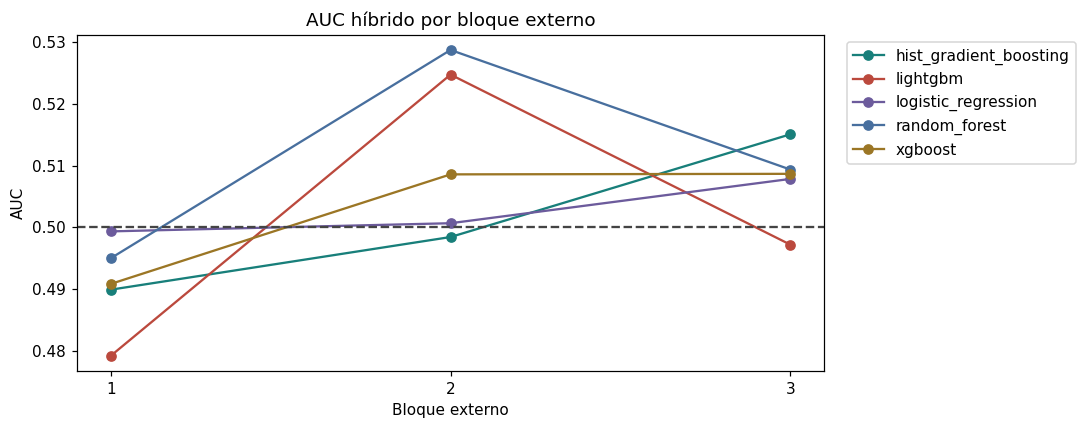

model_name,hist_gradient_boosting,lightgbm,logistic_regression,random_forest,xgboost
Empresa,,,,,
AAPL,0.4707,0.4873,0.4688,0.4926,0.4802
MSFT,0.4883,0.4862,0.5039,0.4852,0.5034
NVDA,0.4837,0.4940,0.5189,0.5180,0.4920
TSLA,0.5418,0.5078,0.5033,0.5256,0.5198


In [7]:
fold_rows = detail.loc[detail["scope"].eq("outer_fold") & detail["dataset_type"].eq("hybrid")].copy()
fold_rows["bloque"] = fold_rows["group"].astype(float).astype(int)
fold_auc = fold_rows.pivot(index="bloque", columns="model_name", values="roc_auc")
ax = fold_auc.plot(marker="o", color=["#187f7a", "#bb493d", "#6c5b9c", "#486f9e", "#9b7625"])
ax.axhline(0.5, color="#444444", linestyle="--")
ax.set(title="AUC híbrido por bloque externo", xlabel="Bloque externo", ylabel="AUC", xticks=[1, 2, 3])
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
by_ticker = detail.loc[detail["scope"].eq("ticker") & detail["dataset_type"].eq("hybrid")]
display(by_ticker.pivot(index="group", columns="model_name", values="roc_auc").rename_axis("Empresa").style.format("{:.4f}"))

## 7. Incertidumbre: ¿la diferencia es compatible con cero?

Los intervalos remuestrean bloques de fechas y mantienen juntas las empresas y las predicciones de los modelos comparados. Se muestran tres comparaciones con bloques de veinte sesiones. Si el intervalo cruza cero, esta estimación no establece una mejora positiva concluyente.

Son intervalos exploratorios de predicciones fijas, sin corrección por comparaciones múltiples ni reentrenamiento en cada réplica.

,dataset_type,model_name,reference_dataset,reference_model,auc_delta,delta_low,delta_high
17,lag_1,lightgbm,hybrid,lightgbm,-0.0008,-0.0193,0.0132
37,relative_features,hist_gradient_boosting,hybrid,hist_gradient_boosting,0.0176,-0.0096,0.0477
60,weighted_sentiment,random_forest,hybrid,random_forest,0.0056,-0.0041,0.0156


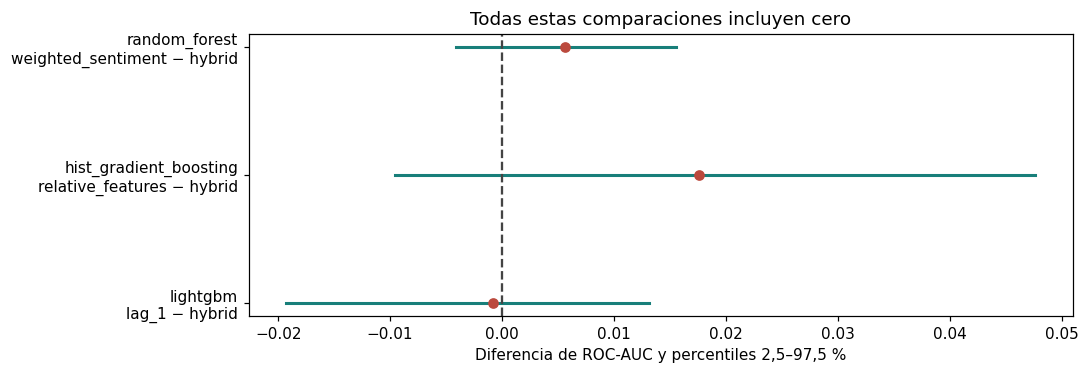

,intervalos,incluyen_cero,mejoras_positivas_excluyendo_cero
0,62,61,0


In [8]:
wanted = {("relative_features", "hist_gradient_boosting"), ("weighted_sentiment", "random_forest"), ("lag_1", "lightgbm")}
chosen = intervals.loc[
    intervals.apply(lambda row: (row["dataset_type"], row["model_name"]) in wanted, axis=1)
    & intervals["block_sessions"].eq(20)
].copy()
columns = ["dataset_type", "model_name", "reference_dataset", "reference_model", "auc_delta", "delta_low", "delta_high"]
display(chosen[columns].style.format({name: "{:.4f}" for name in ["auc_delta", "delta_low", "delta_high"]}))
fig, ax = plt.subplots(figsize=(10, 3.5))
for y, row in enumerate(chosen.itertuples()):
    ax.plot([row.delta_low, row.delta_high], [y, y], color="#187f7a", linewidth=2)
    ax.scatter(row.auc_delta, y, color="#bb493d", zorder=3)
ax.axvline(0, color="#444444", linestyle="--")
ax.set_yticks(range(len(chosen)), [f"{r.model_name}\n{r.dataset_type} − {r.reference_dataset}" for r in chosen.itertuples()])
ax.set(xlabel="Diferencia de ROC-AUC y percentiles 2,5–97,5 %", title="Todas estas comparaciones incluyen cero")
plt.tight_layout()
plt.show()
display(pd.DataFrame({
    "intervalos": [len(intervals)],
    "incluyen_cero": [((intervals["delta_low"] <= 0) & (intervals["delta_high"] >= 0)).sum()],
    "mejoras_positivas_excluyendo_cero": [(intervals["delta_low"] > 0).sum()],
}))

## 8. Persistencia y sensibilidad al tamaño de bloque

La comparación principal de esta ejecución es LightGBM con retardo 1 frente a su híbrido. El resultado se mantiene incierto al cambiar el tamaño del bloque de remuestreo; no se elige un tamaño por producir el resultado deseado.

In [9]:
lag_intervals = intervals.loc[intervals["dataset_type"].eq("lag_1") & intervals["model_name"].eq("lightgbm")]
display(lag_intervals[["block_sessions", "replicates", "roc_auc", "auc_delta", "delta_low", "delta_high"]]
.style.format({name: "{:.4f}" for name in ["roc_auc", "auc_delta", "delta_low", "delta_high"]}))

,block_sessions,replicates,roc_auc,auc_delta,delta_low,delta_high
16,5,1000,0.4946,-0.0008,-0.0170,0.0120
17,20,1000,0.4946,-0.0008,-0.0193,0.0132
18,60,1000,0.4946,-0.0008,-0.0179,0.0142


## 9. Antecedentes: por qué antes aparecía un AUC mayor

La tabla siguiente es histórica y no pertenece al protocolo corregido. Incluye el ensayo que añadió 65 retardos y ventanas, frente a los dos predictores adicionales del retardo controlado. También cambiaron la alineación horaria, la purga, la búsqueda y el reentrenamiento. No podemos atribuir la diferencia entre etapas a una sola causa.

In [10]:
history = pd.read_csv(ROOT / "reports" / "historical" / "tuning" / "model_progression_summary.csv")
historical_auc = history.set_index("model_name")[[name for name in history.columns if name.endswith("_roc_auc")]]
display(historical_auc.style.format("{:.4f}", na_rep="No ejecutado"))
display(Markdown("**No mezclar tablas:** el AUC histórico 0,5217 de LightGBM con retardos no es el resultado del protocolo corregido."))

,base_initial_roc_auc,hybrid_initial_roc_auc,hybrid_tuned_roc_auc,lagged_tuned_roc_auc
model_name,,,,
logistic_regression,0.5115,0.5011,0.5033,0.5042
random_forest,0.5124,0.5040,0.5010,0.5147
hist_gradient_boosting,0.4930,0.5054,0.5087,0.4957
xgboost,No ejecutado,No ejecutado,0.5026,0.4993
lightgbm,No ejecutado,No ejecutado,0.5119,0.5217


**No mezclar tablas:** el AUC histórico 0,5217 de LightGBM con retardos no es el resultado del protocolo corregido.

## 10. Conclusión

Con estas fuentes, empresas, variables y horizonte **no se demuestra una mejora predictiva robusta del sentimiento**. Los máximos puntuales no constituyen validación independiente, y el AUC no mide rentabilidad económica.

Esto no demuestra que las noticias carezcan de efecto sobre los precios. Indica que este experimento no ha establecido una ventaja consistente. Una confirmación exigiría fijar decisiones antes de evaluar un periodo no consultado.

**Documentación:** [borrador de memoria](../docs/borrador_memoria.md), [resultados detallados](../docs/resultados_revision_temporal.md) y [organización de artefactos](../docs/report_organization.md).